<a href="https://colab.research.google.com/github/saminNazmus201/DeepLearningDataScienceUppsala/blob/master/Exercise2Ass2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn.functional as F
import time
from utils import load_mnist, training_curve_plot

In [3]:
!unzip -q MNIST.zip   #unzip the file

In [12]:
x_train_np, y_train_np, x_test_np, y_test_np = load_mnist()

In [13]:
# We reshape from (60000, 784) to (60000, 1, 28, 28)
x_train = torch.from_numpy(x_train_np).view(-1, 1, 28, 28).float()
x_test = torch.from_numpy(x_test_np).view(-1, 1, 28, 28).float()

y_train = torch.from_numpy(y_train_np).long()
y_test = torch.from_numpy(y_test_np).long()

# Convert One-Hot to Indices if necessary (F.cross_entropy needs indices)
if y_train.dim() > 1:
    y_train = y_train.argmax(dim=1)
    y_test = y_test.argmax(dim=1)

In [19]:
def initialize_network():
    def make_weight(shape):
        w = torch.randn(shape) * torch.sqrt(torch.tensor(2.0 / (shape[1] * shape[2] * shape[3])))
        w.requires_grad = True
        return w

    def make_bias(size):
        return torch.full((size,), 0.01, requires_grad=True)

    # Layer 1: 8 filters, 3x3, 1 input channel
    w1 = make_weight((8, 1, 3, 3))
    b1 = make_bias(8)

    # Layer 4: 16 filters, 3x3, 8 input channels
    w2 = make_weight((16, 8, 3, 3))
    b2 = make_bias(16)

    # Layer 7: 32 filters, 3x3, 16 input channels
    w3 = make_weight((32, 16, 3, 3))
    b3 = make_bias(32)

    # Layer 10: Fully Connected
    # After two 2x2 pools, 28x28 becomes 7x7. 32 channels * 7 * 7 = 1568
    w_fc = torch.randn(10, 1568) * torch.sqrt(torch.tensor(2.0 / 1568))
    w_fc.requires_grad = True
    b_fc = make_bias(10)

    return [w1, w2, w3, w_fc], [b1, b2, b3, b_fc]

In [20]:
def forward_pass_cnn(X, weights, biases):
    w1, w2, w3, w_fc = weights
    b1, b2, b3, b_fc = biases

    # 1, 2, 3: Conv -> ReLU -> MaxPool (28x28 -> 14x14)
    x = F.conv2d(X, w1, b1, stride=1, padding=1)
    x = F.relu(x)
    x = F.max_pool2d(x, kernel_size=2, stride=2)

    # 4, 5, 6: Conv -> ReLU -> MaxPool (14x14 -> 7x7)
    x = F.conv2d(x, w2, b2, stride=1, padding=1)
    x = F.relu(x)
    x = F.max_pool2d(x, kernel_size=2, stride=2)

    # 7, 8: Conv -> ReLU (7x7 stays 7x7)
    x = F.conv2d(x, w3, b3, stride=1, padding=1)
    x = F.relu(x)

    # 9: Flatten
    x = x.view(x.size(0), -1)

    # 10: Fully Connected
    logits = F.linear(x, w_fc, b_fc)

    return logits

In [31]:
# def train_cnn(x_train, y_train, x_test, y_test, num_epochs=10, lr=0.05, batch_size=64):
#     weights, biases = initialize_network()
#     train_costs, test_costs = [], []
#     train_accs, test_accs = [], []

#     for epoch in range(num_epochs):
#         indices = torch.randperm(x_train.size(0))
#         for i in range(0, x_train.size(0), batch_size):
#             batch_idx = indices[i:i+batch_size]
#             x_mini, y_mini = x_train[batch_idx], y_train[batch_idx]

#             logits = forward_pass_cnn(x_mini, weights, biases)
#             loss = F.cross_entropy(logits, y_mini)
#             loss.backward()

#             with torch.no_grad():
#                 for w, b in zip(weights, biases):
#                     w -= lr * w.grad
#                     b -= lr * b.grad
#                     w.grad.zero_()
#                     b.grad.zero_()

#         with torch.no_grad():
#             # Training metrics
#             train_logits = forward_pass_cnn(x_train, weights, biases)
#             train_loss = F.cross_entropy(train_logits, y_train).item()
#             train_acc = (train_logits.argmax(dim=1) == y_train).float().mean().item()

#             # Test metrics
#             test_logits = forward_pass_cnn(x_test, weights, biases)
#             test_loss = F.cross_entropy(test_logits, y_test).item()
#             test_acc = (test_logits.argmax(dim=1) == y_test).float().mean().item()

#             train_costs.append(train_loss)
#             test_costs.append(test_loss)
#             train_accs.append(train_acc)
#             test_accs.append(test_acc)

#     return weights, biases, train_costs, test_costs, train_accs, test_accs

def train_cnn(x_train, y_train, x_test, y_test, num_epochs=10, lr=0.05, batch_size=64):
    weights, biases = initialize_network()
    train_costs, test_costs = [], []
    train_accs, test_accs = [], []

    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        indices = torch.randperm(x_train.size(0))
        for i in range(0, x_train.size(0), batch_size):
            batch_idx = indices[i:i+batch_size]
            x_mini, y_mini = x_train[batch_idx], y_train[batch_idx]

            logits = forward_pass_cnn(x_mini, weights, biases)
            loss = F.cross_entropy(logits, y_mini)
            loss.backward()

            with torch.no_grad():
                for w, b in zip(weights, biases):
                    w -= lr * w.grad
                    b -= lr * b.grad
                    w.grad.zero_()
                    b.grad.zero_()

        # --- EVALUATION PHASE (Optimized for CNN) ---
        # We define a helper to calculate metrics in batches so it doesn't hang
        def get_metrics(X, Y):
            total_loss = 0
            total_correct = 0
            eval_batch = 512 # Large enough to be fast, small enough for memory
            with torch.no_grad():
                for j in range(0, X.size(0), eval_batch):
                    x_b, y_b = X[j:j+eval_batch], Y[j:j+eval_batch]
                    out = forward_pass_cnn(x_b, weights, biases)
                    total_loss += F.cross_entropy(out, y_b).item() * x_b.size(0)
                    total_correct += (out.argmax(dim=1) == y_b).sum().item()
            return total_loss / X.size(0), total_correct / X.size(0)

        # Calculate Train and Test metrics
        t_loss, t_acc = get_metrics(x_train, y_train)
        v_loss, v_acc = get_metrics(x_test, y_test)

        # Store for the graph
        train_costs.append(t_loss)
        test_costs.append(v_loss)
        train_accs.append(t_acc)
        test_accs.append(v_acc)


        print(f"Epoch {epoch}: Loss {t_loss:.4f}, Test Acc {v_acc:.4f}")

    return weights, biases, train_costs, test_costs, train_accs, test_accs

Epoch 0: Loss 0.0905, Test Acc 0.9710
Epoch 1: Loss 0.0724, Test Acc 0.9777
Epoch 2: Loss 0.0428, Test Acc 0.9861
Epoch 3: Loss 0.0387, Test Acc 0.9854
Epoch 4: Loss 0.0325, Test Acc 0.9865
Epoch 5: Loss 0.0251, Test Acc 0.9875
Epoch 6: Loss 0.0285, Test Acc 0.9866
Epoch 7: Loss 0.0232, Test Acc 0.9874
Epoch 8: Loss 0.0346, Test Acc 0.9855
Epoch 9: Loss 0.0192, Test Acc 0.9885


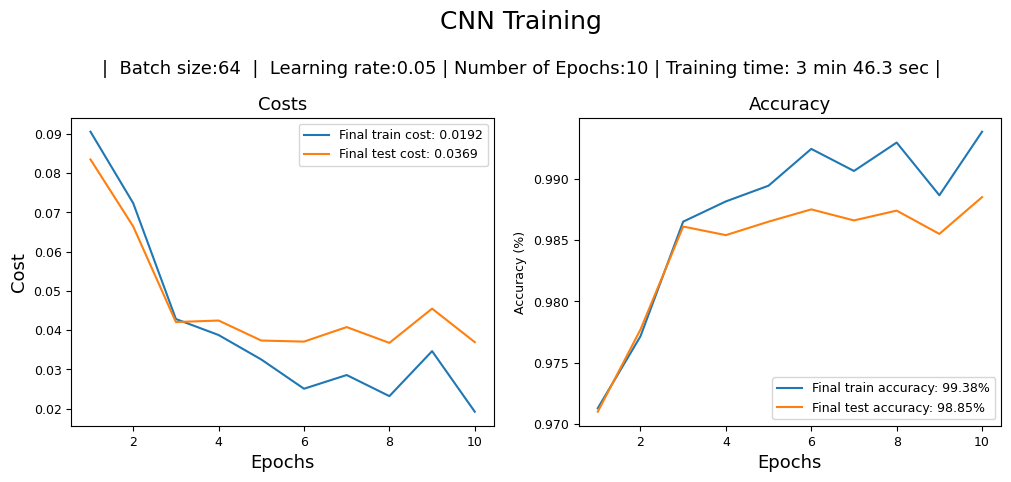

In [32]:
import time
from utils import training_curve_plot

# Parameters
learning_rate = 0.05
batch_size = 64
num_epochs = 10

# Reshape data once to 4D: (Batch, Channels, Height, Width)
x_train_cnn = x_train.view(-1, 1, 28, 28)
x_test_cnn = x_test.view(-1, 1, 28, 28)

start_time = time.time()

# Train
w_cnn, b_cnn, t_costs, v_costs, t_accs, v_accs = train_cnn(
    x_train_cnn, y_train, x_test_cnn, y_test,
    num_epochs=num_epochs, lr=learning_rate, batch_size=batch_size
)

# Plotting - Pass all four lists
training_curve_plot(
    "CNN Training",
    t_costs, v_costs, t_accs, v_accs,
    batch_size, learning_rate, num_epochs, time.time() - start_time
)